# 🏠 House Price Prediction

**Objective:** Predict house prices using property features such as size, quality, location, and amenities.

**Dataset:** Ames Housing Dataset (Kaggle)

**Models Used:** Linear Regression, Gradient Boosting Regressor

**Evaluation Metrics:** MAE, RMSE, R² Score


---
## 1. Import Libraries


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

print("All libraries imported successfully.")

---
## 2. Load the Dataset

>**Download:** https://www.kaggle.com/datasets/prevek18/ames-housing-dataset  
>Save the file as `AmesHousing.csv` in the same folder as this notebook.

**Key Columns:**

| Column | Description |
|---|---|
| `SalePrice` | **Target** — Sale price of the house |
| `Gr Liv Area` | Above grade living area (sq ft) |
| `Overall Qual` | Overall material and finish quality (1–10) |
| `Garage Cars` | Garage capacity in car count |
| `Total Bsmt SF` | Total basement area (sq ft) |
| `Year Built` | Original construction year |
| `Neighborhood` | Physical location within Ames |
| `Bedroom AbvGr` | Bedrooms above ground |
| `Full Bath` | Full bathrooms above grade |


In [11]:
df = pd.read_csv('AmesHousing.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nFirst 5 rows:")
df.head()


Dataset shape: (2930, 82)

First 5 rows:


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


---
## 3. Exploratory Data Analysis (EDA)


### 3.1 Basic Info and Summary Statistics


In [12]:
print("=== Dataset Info ===")
df.info()


=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null   object

In [13]:
print("=== Descriptive Statistics (Numerical) ===")
df.describe().round(2)


=== Descriptive Statistics (Numerical) ===


,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
count,2930.00,2.930000e+03,2930.00,2440.00,2930.00,2930.00,2930.00,2930.00,2930.00,2907.00,...,2930.00,2930.00,2930.00,2930.00,2930.00,2930.00,2930.00,2930.00,2930.00,2930.00
mean,1465.50,7.144645e+08,57.39,69.22,10147.92,6.09,5.56,1971.36,1984.27,101.90,...,93.75,47.53,23.01,2.59,16.00,2.24,50.64,6.22,2007.79,180796.06
std,845.96,1.887308e+08,42.64,23.37,7880.02,1.41,1.11,30.25,20.86,179.11,...,126.36,67.48,64.14,25.14,56.09,35.60,566.34,2.71,1.32,79886.69
min,1.00,5.263011e+08,20.00,21.00,1300.00,1.00,1.00,1872.00,1950.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,2006.00,12789.00
25%,733.25,5.284770e+08,20.00,58.00,7440.25,5.00,5.00,1954.00,1965.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,4.00,2007.00,129500.00
50%,1465.50,5.354536e+08,50.00,68.00,9436.50,6.00,5.00,1973.00,1993.00,0.00,...,0.00,27.00,0.00,0.00,0.00,0.00,0.00,6.00,2008.00,160000.00
75%,2197.75,9.071811e+08,70.00,80.00,11555.25,7.00,6.00,2001.00,2004.00,164.00,...,168.00,70.00,0.00,0.00,0.00,0.00,0.00,8.00,2009.00,213500.00
max,2930.00,1.007100e+09,190.00,313.00,215245.00,10.00,9.00,2010.00,2010.00,1600.00,...,1424.00,742.00,1012.00,508.00,576.00,800.00,17000.00,12.00,2010.00,755000.00


In [14]:
# Ames has many missing values worth examining
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(f"=== Missing Values === ({len(missing)} columns affected)\n")
print(missing.to_string())


=== Missing Values === (27 columns affected)

Pool QC           2917
Misc Feature      2824
Alley             2732
Fence             2358
Mas Vnr Type      1775
Fireplace Qu      1422
Lot Frontage       490
Garage Cond        159
Garage Qual        159
Garage Finish      159
Garage Yr Blt      159
Garage Type        157
Bsmt Exposure       83
BsmtFin Type 2      81
Bsmt Cond           80
Bsmt Qual           80
BsmtFin Type 1      80
Mas Vnr Area        23
Bsmt Half Bath       2
Bsmt Full Bath       2
BsmtFin SF 1         1
Garage Cars          1
Garage Area          1
Total Bsmt SF        1
Bsmt Unf SF          1
BsmtFin SF 2         1
Electrical           1


### 3.2 Target Variable - SalePrice Distribution


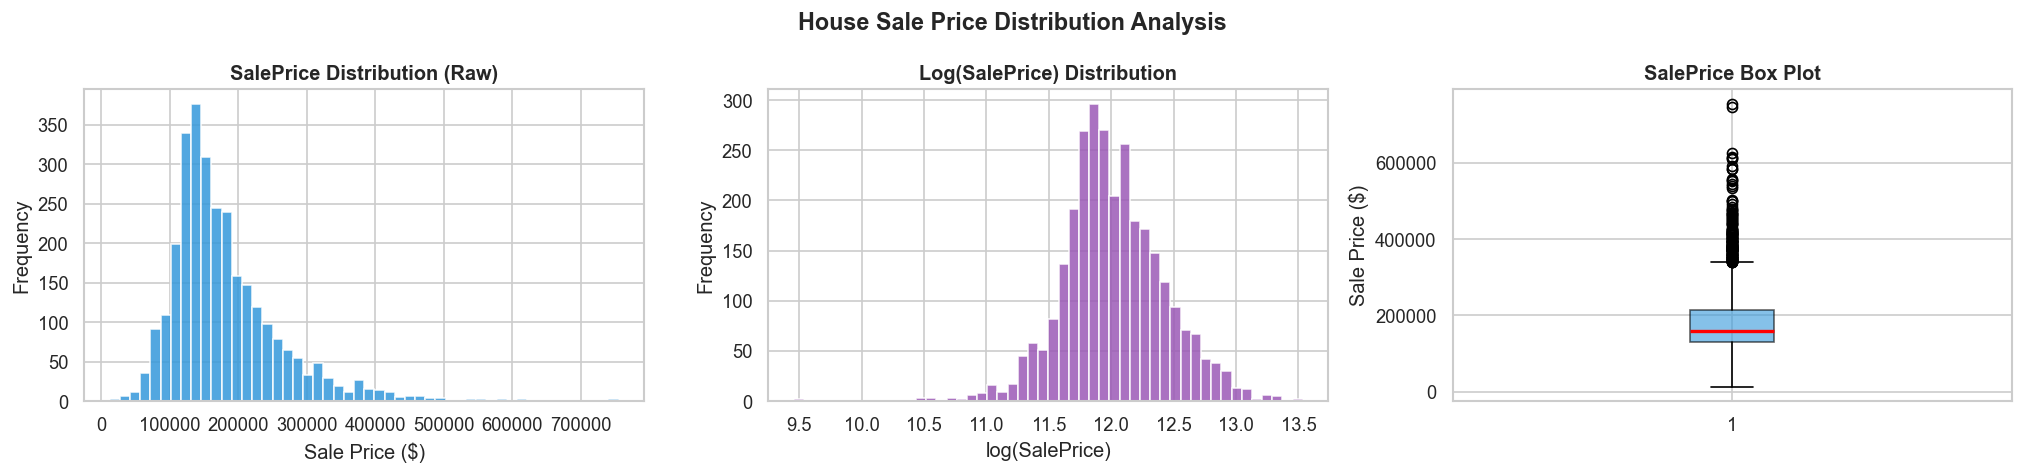

Min price    : $12,789
Max price    : $755,000
Mean price   : $180,796
Median price : $160,000
Skewness     : 1.744  (>1 = right-skewed, log transform recommended)


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4))

axes[0].hist(df['SalePrice'], bins=50, color='#3498db', edgecolor='white', alpha=0.85)
axes[0].set_title('SalePrice Distribution (Raw)', fontweight='bold')
axes[0].set_xlabel('Sale Price ($)')
axes[0].set_ylabel('Frequency')

axes[1].hist(np.log1p(df['SalePrice']), bins=50, color='#9b59b6', edgecolor='white', alpha=0.85)
axes[1].set_title('Log(SalePrice) Distribution', fontweight='bold')
axes[1].set_xlabel('log(SalePrice)')
axes[1].set_ylabel('Frequency')

axes[2].boxplot(df['SalePrice'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='#3498db', alpha=0.6),
                medianprops=dict(color='red', lw=2))
axes[2].set_title('SalePrice Box Plot', fontweight='bold')
axes[2].set_ylabel('Sale Price ($)')

plt.suptitle('House Sale Price Distribution Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('hp_01_price_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Min price    : ${df['SalePrice'].min():,.0f}")
print(f"Max price    : ${df['SalePrice'].max():,.0f}")
print(f"Mean price   : ${df['SalePrice'].mean():,.0f}")
print(f"Median price : ${df['SalePrice'].median():,.0f}")
print(f"Skewness     : {df['SalePrice'].skew():.3f}  (>1 = right-skewed, log transform recommended)")


### 3.3 Top Numerical Features vs SalePrice (Scatter Plots)


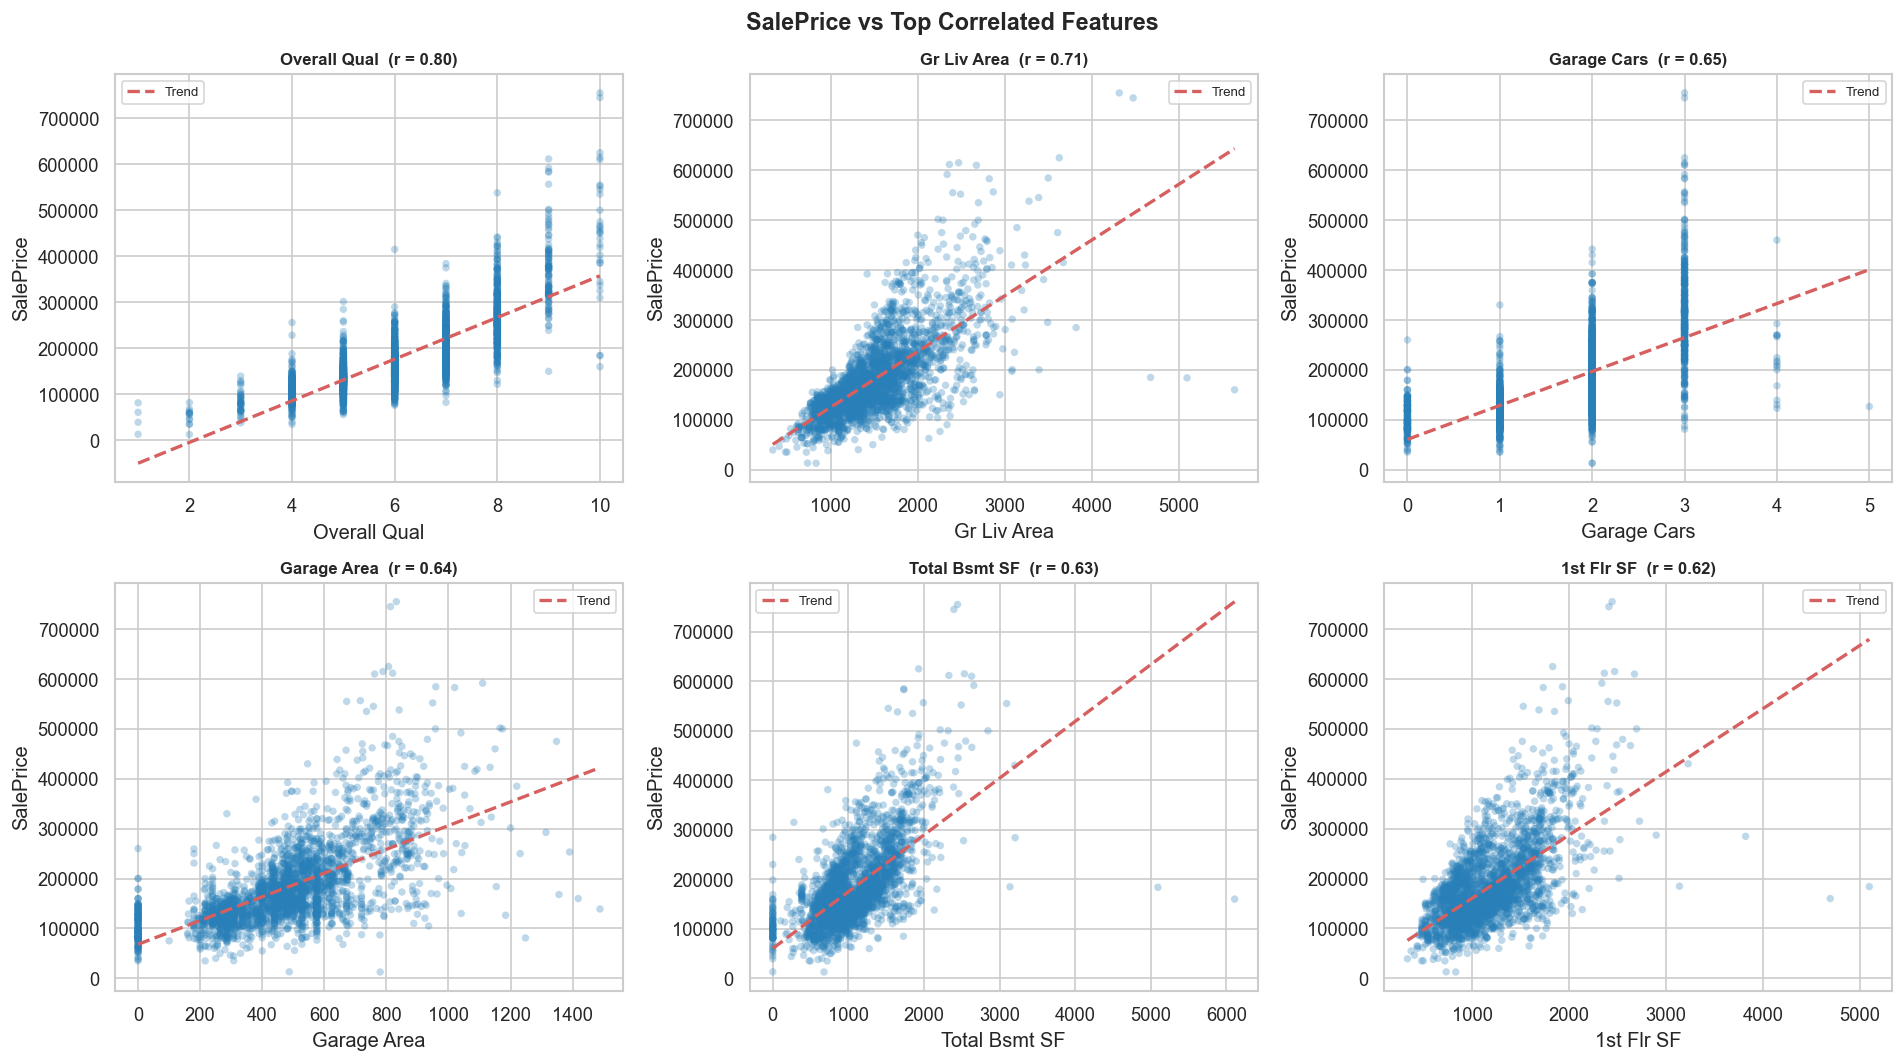

In [16]:
# Select top numerical features most correlated with SalePrice
num_df = df.select_dtypes(include=np.number).dropna()
top_features = num_df.corr()['SalePrice'].drop('SalePrice').abs().sort_values(ascending=False).head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(top_features):
    ax = axes[i]
    ax.scatter(df[col], df['SalePrice'], alpha=0.3, color='#2980b9', edgecolors='none', s=20)
    z = np.polyfit(df[col].fillna(df[col].median()), df['SalePrice'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df[col].min(), df[col].max(), 100)
    ax.plot(x_line, p(x_line), 'r--', lw=2, label='Trend')
    corr = df[col].corr(df['SalePrice'])
    ax.set_title(f'{col}  (r = {corr:.2f})', fontweight='bold', fontsize=10)
    ax.set_xlabel(col)
    ax.set_ylabel('SalePrice')
    ax.legend(fontsize=8)

plt.suptitle('SalePrice vs Top Correlated Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('hp_03_price_vs_features.png', dpi=150, bbox_inches='tight')
plt.show()


### 3.4 SalePrice by Neighborhood
Ames has rich neighborhood data, a key price driver


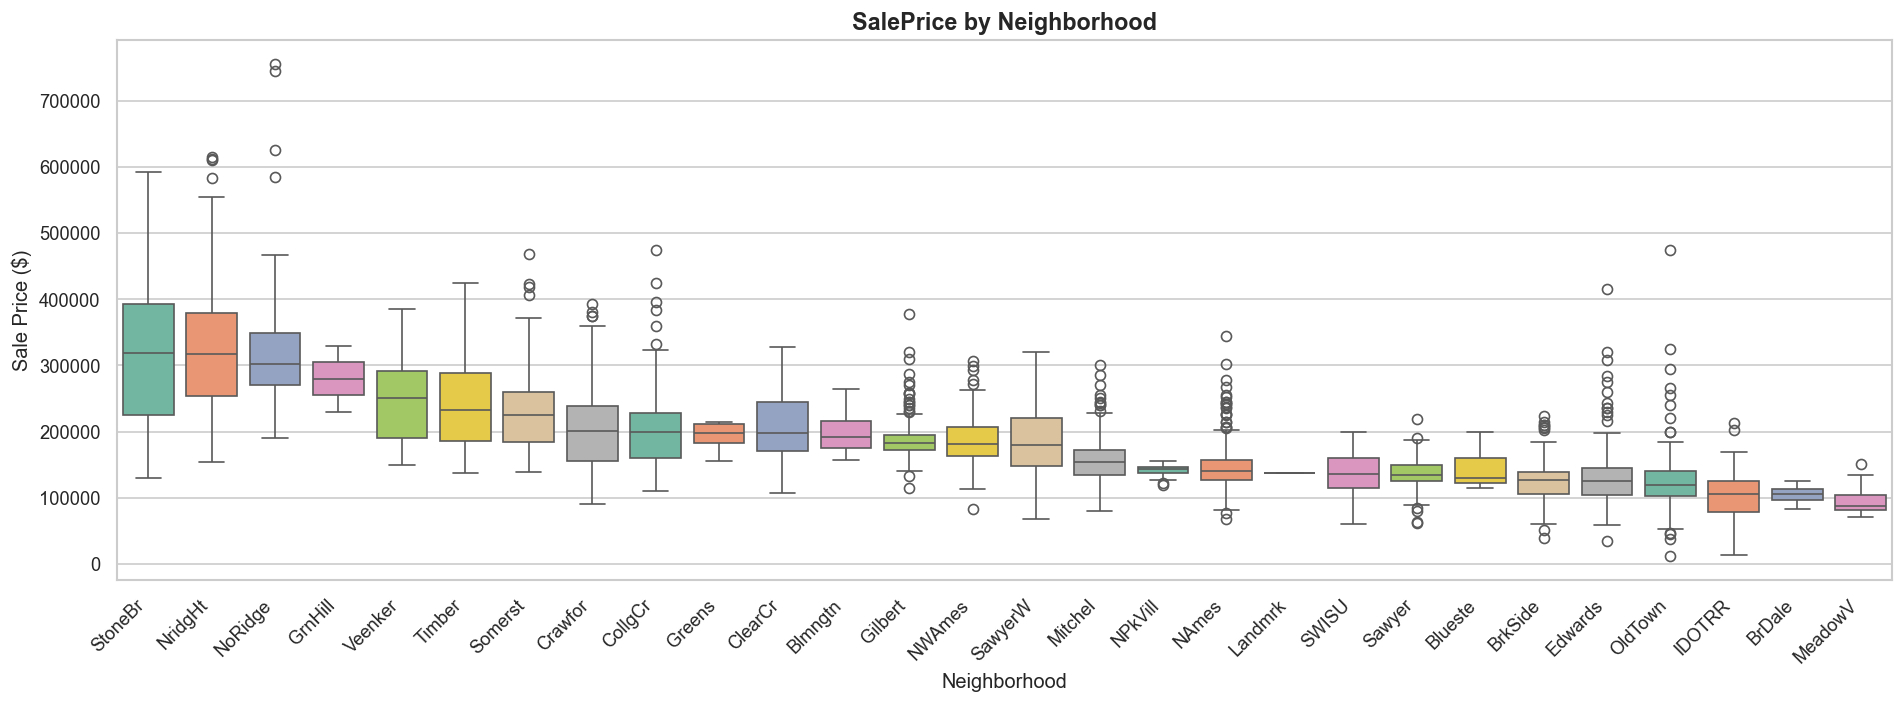

In [17]:
plt.figure(figsize=(16, 6))
order = df.groupby('Neighborhood')['SalePrice'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='Neighborhood', y='SalePrice', order=order, palette='Set2')
plt.xticks(rotation=45, ha='right')
plt.title('SalePrice by Neighborhood', fontsize=14, fontweight='bold')
plt.xlabel('Neighborhood')
plt.ylabel('Sale Price ($)')
plt.tight_layout()
plt.savefig('hp_04_neighborhood_prices.png', dpi=150, bbox_inches='tight')
plt.show()


### 3.5 Overall Quality vs SalePrice
Overall Qual is the single strongest predictor in this dataset


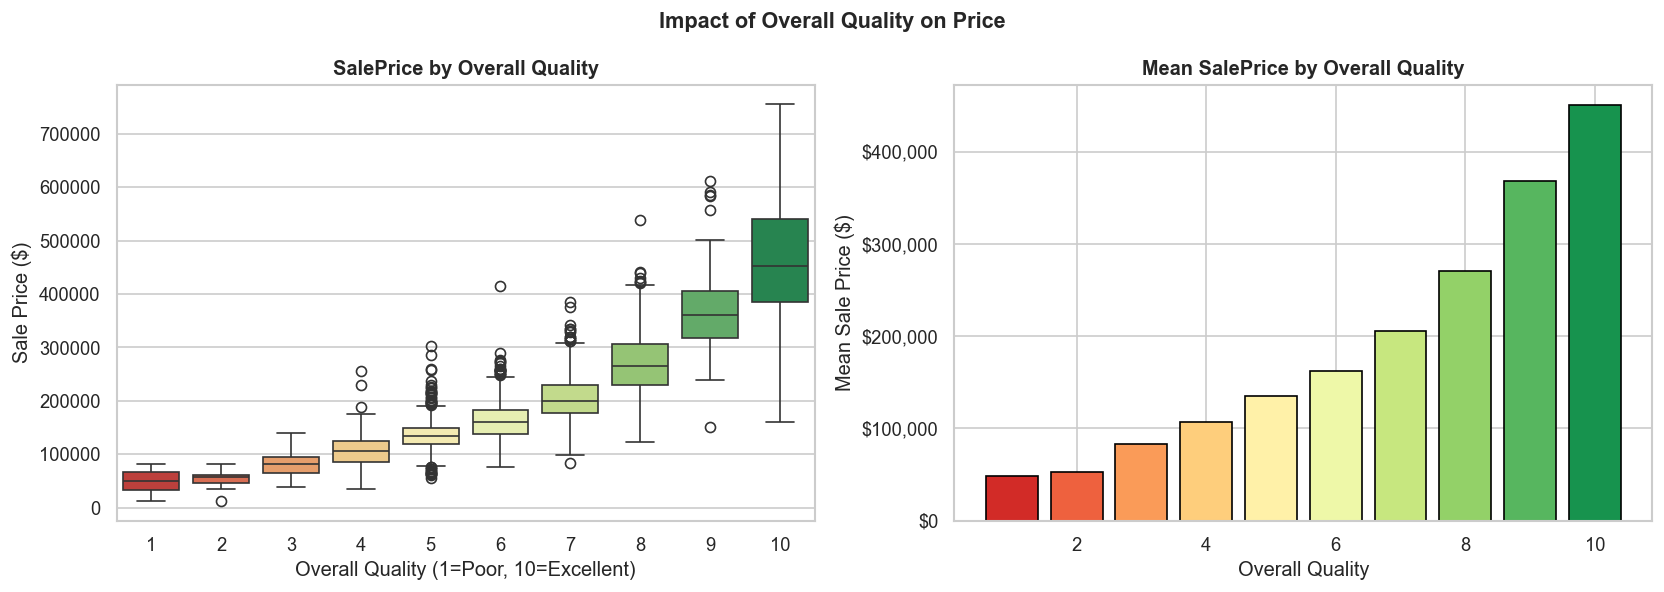

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot
sns.boxplot(data=df, x='Overall Qual', y='SalePrice', ax=axes[0], palette='RdYlGn')
axes[0].set_title('SalePrice by Overall Quality', fontweight='bold')
axes[0].set_xlabel('Overall Quality (1=Poor, 10=Excellent)')
axes[0].set_ylabel('Sale Price ($)')

# Mean price per quality level
mean_by_qual = df.groupby('Overall Qual')['SalePrice'].mean()
axes[1].bar(mean_by_qual.index, mean_by_qual.values,
            color=sns.color_palette('RdYlGn', len(mean_by_qual)), edgecolor='black')
axes[1].set_title('Mean SalePrice by Overall Quality', fontweight='bold')
axes[1].set_xlabel('Overall Quality')
axes[1].set_ylabel('Mean Sale Price ($)')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.suptitle('Impact of Overall Quality on Price', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('hp_05_quality_vs_price.png', dpi=150, bbox_inches='tight')
plt.show()


### 3.6 Correlation Heatmap (Top 15 Features)
79 features total - showing top 15 most correlated with SalePrice only


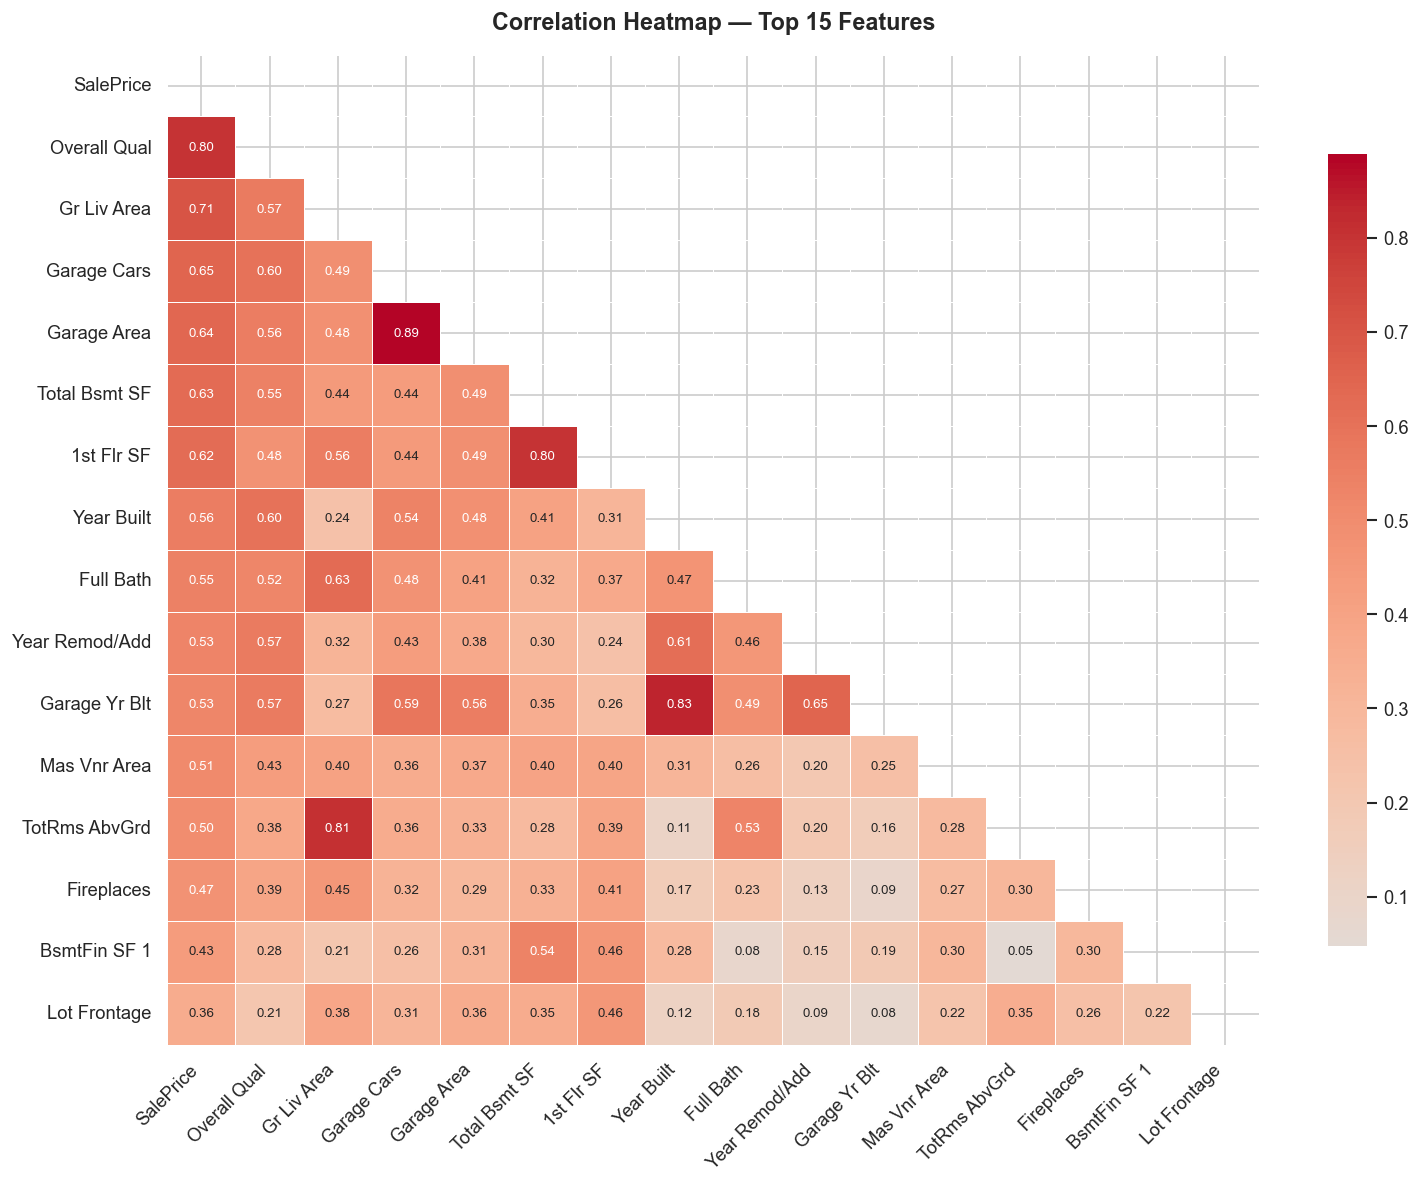


Top 10 correlations with SalePrice:
Overall Qual      0.799262
Gr Liv Area       0.706780
Garage Cars       0.647877
Garage Area       0.640401
Total Bsmt SF     0.632280
1st Flr SF        0.621676
Year Built        0.558426
Full Bath         0.545604
Year Remod/Add    0.532974
Garage Yr Blt     0.526965


In [19]:
num_df = df.select_dtypes(include=np.number)
top15 = num_df.corr()['SalePrice'].abs().sort_values(ascending=False).head(16).index

plt.figure(figsize=(13, 10))
corr = num_df[top15].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={'size': 8},
            cbar_kws={'shrink': 0.8})

plt.title('Correlation Heatmap — Top 15 Features', fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('hp_06_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 10 correlations with SalePrice:")
print(num_df.corr()['SalePrice'].drop('SalePrice').abs().sort_values(ascending=False).head(10).to_string())


### 3.7 Outlier Analysis


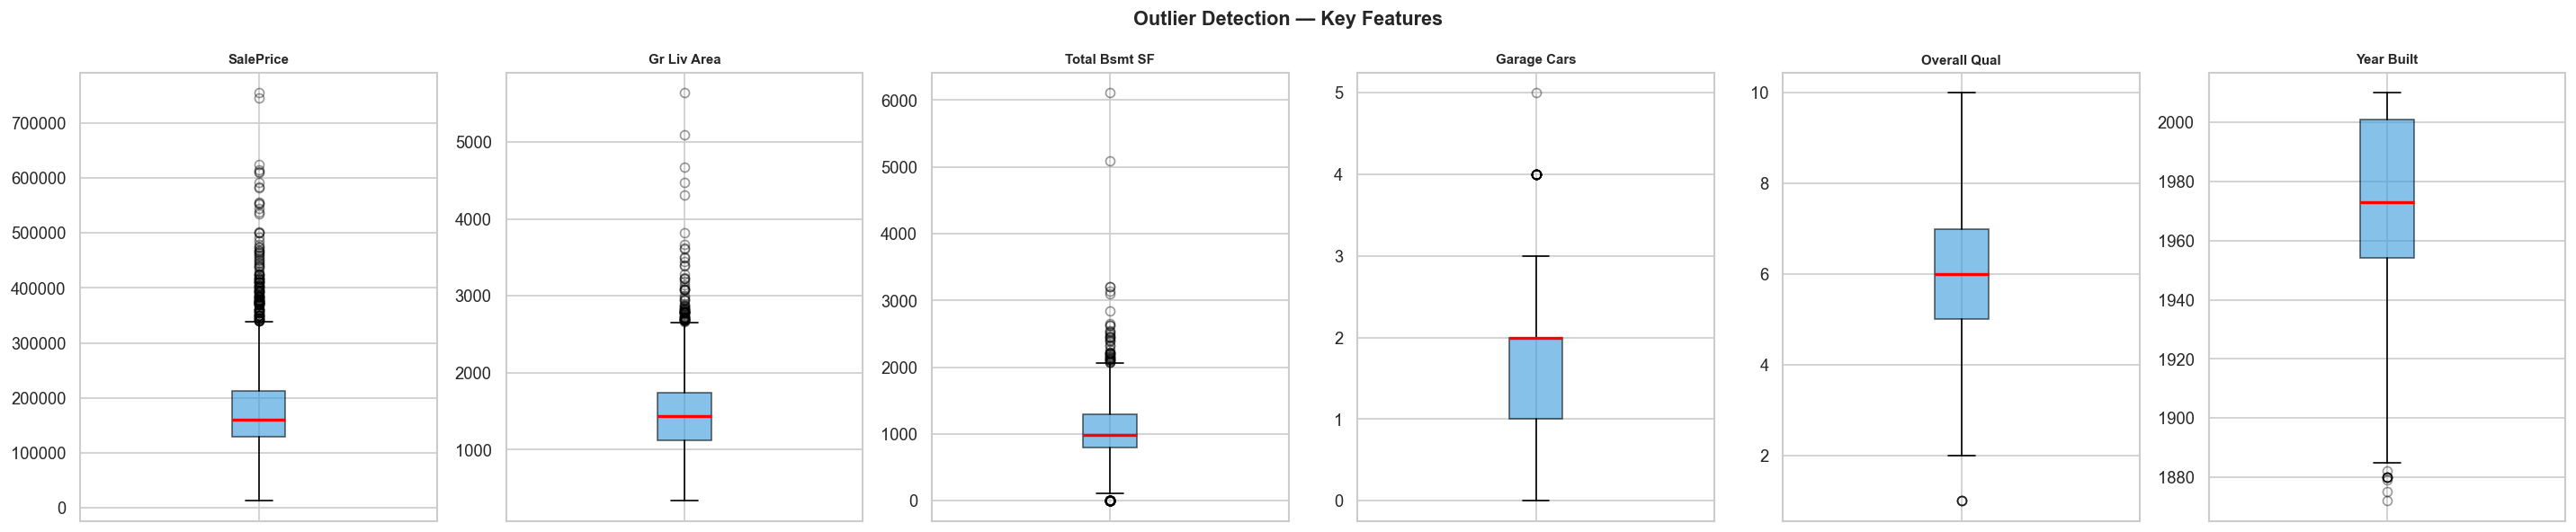

In [20]:
key_cols = ['SalePrice', 'Gr Liv Area', 'Total Bsmt SF', 'Garage Cars', 'Overall Qual', 'Year Built']
key_cols = [c for c in key_cols if c in df.columns]

fig, axes = plt.subplots(1, len(key_cols), figsize=(4*len(key_cols), 5))

for ax, col in zip(axes, key_cols):
    ax.boxplot(df[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor='#3498db', alpha=0.6),
               medianprops=dict(color='red', lw=2),
               flierprops=dict(marker='o', color='#e74c3c', alpha=0.4))
    ax.set_title(col, fontweight='bold', fontsize=9)
    ax.tick_params(axis='x', labelbottom=False)

plt.suptitle('Outlier Detection — Key Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('hp_07_outliers.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 4. Data Preprocessing
> Ames has 79 features, missing values, and many categorical columns

Steps:
1. Drop low-value / high-missing columns
2. Fill missing values
3. Encode categorical features
4. Feature engineering (new features)
5. Train/test split
6. Feature scaling - before vs after


### 4.1 Before Preprocessing - Raw Data Sample


In [21]:
print("=== RAW DATA (first 3 rows, first 15 columns) ===")
print(df.iloc[:3, :15].to_string())
print(f"\nTotal columns : {df.shape[1]}")
print(f"Total rows    : {df.shape[0]}")
print(f"\nData types summary:")
print(df.dtypes.value_counts().to_string())


=== RAW DATA (first 3 rows, first 15 columns) ===
   Order        PID  MS SubClass MS Zoning  Lot Frontage  Lot Area Street Alley Lot Shape Land Contour Utilities Lot Config Land Slope Neighborhood Condition 1
0      1  526301100           20        RL         141.0     31770   Pave   NaN       IR1          Lvl    AllPub     Corner        Gtl        NAmes        Norm
1      2  526350040           20        RH          80.0     11622   Pave   NaN       Reg          Lvl    AllPub     Inside        Gtl        NAmes       Feedr
2      3  526351010           20        RL          81.0     14267   Pave   NaN       IR1          Lvl    AllPub     Corner        Gtl        NAmes        Norm

Total columns : 82
Total rows    : 2930

Data types summary:
object     43
int64      28
float64    11


### 4.2 Drop Irrelevant and High-Missing Columns
Ames has columns with 80%+ missing values

In [22]:
df_processed = df.copy()

# Drop columns with more than 40% missing values
threshold = 0.4 * len(df_processed)
high_missing = [col for col in df_processed.columns if df_processed[col].isnull().sum() > threshold]
print(f"Dropping {len(high_missing)} high-missing columns: {high_missing}")
df_processed.drop(columns=high_missing, inplace=True)

# Drop ID column if present
id_cols = ['Order', 'PID']
id_cols = [c for c in id_cols if c in df_processed.columns]
df_processed.drop(columns=id_cols, inplace=True, errors='ignore')
print(f"Dropped ID columns: {id_cols}")
print(f"\nRemaining columns: {df_processed.shape[1]}")


Dropping 6 high-missing columns: ['Alley', 'Mas Vnr Type', 'Fireplace Qu', 'Pool QC', 'Fence', 'Misc Feature']
Dropped ID columns: ['Order', 'PID']

Remaining columns: 74


### 4.3 Handle Missing Values
fill remaining NaNs intelligently

In [23]:
# Numerical: fill with median
num_cols = df_processed.select_dtypes(include=np.number).columns
for col in num_cols:
    if df_processed[col].isnull().sum() > 0:
        df_processed[col].fillna(df_processed[col].median(), inplace=True)

# Categorical: fill with mode
cat_cols = df_processed.select_dtypes(include='object').columns
for col in cat_cols:
    if df_processed[col].isnull().sum() > 0:
        df_processed[col].fillna(df_processed[col].mode()[0], inplace=True)

print(f"Missing values remaining: {df_processed.isnull().sum().sum()}")
print("All missing values handled.")


Missing values remaining: 0
All missing values handled.


### 4.4 Encode Categorical Features
Ames has many more categorical columns

In [24]:
# Before encoding
cat_cols = df_processed.select_dtypes(include='object').columns.tolist()
print(f"Categorical columns to encode ({len(cat_cols)}):")
print(cat_cols)

# Label encode all categorical columns
le = LabelEncoder()
for col in cat_cols:
    df_processed[col] = le.fit_transform(df_processed[col].astype(str))

print(f"\nAll {len(cat_cols)} categorical columns encoded.")
print(f"Dataset shape after encoding: {df_processed.shape}")


Categorical columns to encode (37):
['MS Zoning', 'Street', 'Lot Shape', 'Land Contour', 'Utilities', 'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1', 'Condition 2', 'Bldg Type', 'House Style', 'Roof Style', 'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin Type 2', 'Heating', 'Heating QC', 'Central Air', 'Electrical', 'Kitchen Qual', 'Functional', 'Garage Type', 'Garage Finish', 'Garage Qual', 'Garage Cond', 'Paved Drive', 'Sale Type', 'Sale Condition']

All 37 categorical columns encoded.
Dataset shape after encoding: (2930, 74)


### 4.5 Feature Engineering
create meaningful composite features

In [25]:
# New features that capture interactions
df_processed['house_age']         = 2024 - df_processed['Year Built']
df_processed['remod_age']         = 2024 - df_processed.get('Year Remod/Add', df_processed['Year Built'])
df_processed['total_sf']          = df_processed.get('Total Bsmt SF', 0) + df_processed.get('Gr Liv Area', 0)
df_processed['total_bathrooms']   = (df_processed.get('Full Bath', 0) +
                                     df_processed.get('Half Bath', 0) * 0.5 +
                                     df_processed.get('Bsmt Full Bath', 0) +
                                     df_processed.get('Bsmt Half Bath', 0) * 0.5)
df_processed['total_porch_sf']    = (df_processed.get('Open Porch SF', 0) +
                                     df_processed.get('Enclosed Porch', 0) +
                                     df_processed.get('3Ssn Porch', 0) +
                                     df_processed.get('Screen Porch', 0))

print("New features created:")
print("   house_age       — how old the house is")
print("   remod_age       — years since last remodel")
print("   total_sf        — basement + living area combined")
print("   total_bathrooms — weighted count of all bathrooms")
print("   total_porch_sf  — all porch areas combined")
print(f"\nFinal feature count: {df_processed.shape[1]}")


New features created:
   house_age       — how old the house is
   remod_age       — years since last remodel
   total_sf        — basement + living area combined
   total_bathrooms — weighted count of all bathrooms
   total_porch_sf  — all porch areas combined

Final feature count: 79


### 4.6 Train/Test Split


In [26]:
X = df_processed.drop(columns=['SalePrice'])
y = df_processed['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Features     : {X.shape[1]}")
print(f"Training set : {X_train.shape[0]} samples")
print(f"Test set     : {X_test.shape[0]} samples")


Features     : 78
Training set : 2344 samples
Test set     : 586 samples


### 4.7 Feature Scaling - Before vs After


In [27]:
print("=== RAW Feature Statistics (Before Scaling) — Top 8 features ===\n")
raw_stats = X_train.describe().loc[['mean', 'std', 'min', 'max']].T.head(8)
raw_stats.columns = ['Mean', 'Std Dev', 'Min', 'Max']
print(raw_stats.round(2).to_string())


=== RAW Feature Statistics (Before Scaling) — Top 8 features ===

                  Mean  Std Dev     Min       Max
MS SubClass      57.31    42.80    20.0     190.0
MS Zoning         4.97     0.86     0.0       6.0
Lot Frontage     69.01    21.37    21.0     313.0
Lot Area      10127.86  8050.91  1300.0  215245.0
Street            1.00     0.07     0.0       1.0
Lot Shape         1.95     1.41     0.0       3.0
Land Contour      2.78     0.69     0.0       3.0
Utilities         0.00     0.06     0.0       2.0


In [29]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)

print("=== SCALED Feature Statistics (After Scaling) — Top 8 features ===\n")
scaled_stats = X_train_scaled_df.describe().loc[['mean', 'std', 'min', 'max']].T.head(8)
scaled_stats.columns = ['Mean', 'Std Dev', 'Min', 'Max']
print(scaled_stats.round(4).to_string())
print("\nAll features now have mean ≈ 0 and std ≈ 1")


=== SCALED Feature Statistics (After Scaling) — Top 8 features ===

              Mean  Std Dev      Min      Max
MS SubClass   -0.0   1.0002  -0.8718   3.1008
MS Zoning     -0.0   1.0002  -5.7470   1.1914
Lot Frontage  -0.0   1.0002  -2.2470  11.4208
Lot Area       0.0   1.0002  -1.0967  25.4830
Street         0.0   1.0002 -14.5633   0.0687
Lot Shape      0.0   1.0002  -1.3803   0.7450
Land Contour   0.0   1.0002  -4.0127   0.3138
Utilities     -0.0   1.0002  -0.0344  32.2613

All features now have mean ≈ 0 and std ≈ 1


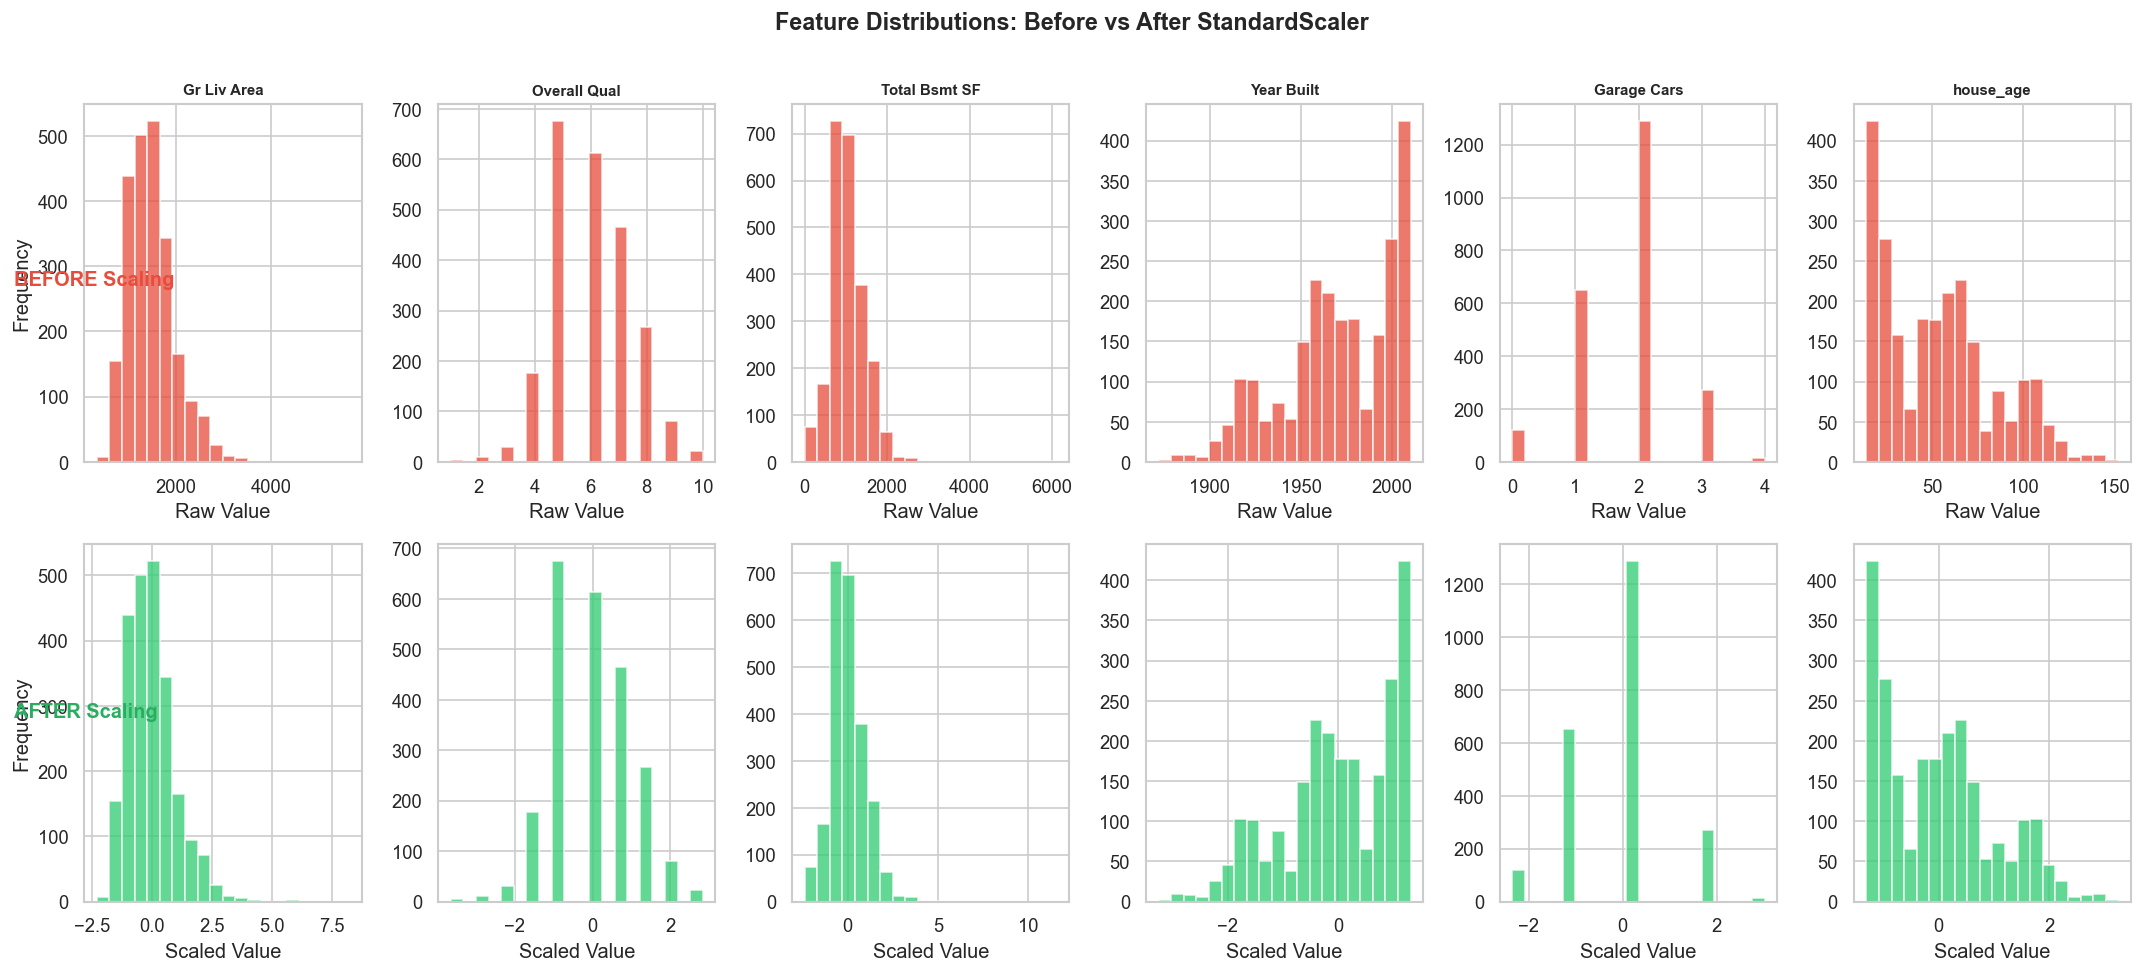

In [30]:
# Visual before vs after — pick 6 key numerical features
compare_cols = ['Gr Liv Area', 'Overall Qual', 'Total Bsmt SF', 'Year Built', 'Garage Cars', 'house_age']
compare_cols = [c for c in compare_cols if c in X_train.columns]

fig, axes = plt.subplots(2, len(compare_cols), figsize=(18, 8))

for i, col in enumerate(compare_cols):
    axes[0, i].hist(X_train[col], bins=20, color='#e74c3c', alpha=0.75, edgecolor='white')
    axes[0, i].set_title(col, fontweight='bold', fontsize=9)
    axes[0, i].set_xlabel('Raw Value')
    if i == 0:
        axes[0, i].set_ylabel('Frequency')

    axes[1, i].hist(X_train_scaled_df[col], bins=20, color='#2ecc71', alpha=0.75, edgecolor='white')
    axes[1, i].set_xlabel('Scaled Value')
    if i == 0:
        axes[1, i].set_ylabel('Frequency')

fig.text(0.01, 0.73, 'BEFORE Scaling', va='center', ha='left',
         fontsize=12, fontweight='bold', color='#e74c3c')
fig.text(0.01, 0.28, 'AFTER Scaling', va='center', ha='left',
         fontsize=12, fontweight='bold', color='#27ae60')

plt.suptitle('Feature Distributions: Before vs After StandardScaler',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('hp_08_scaling_before_after.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Model Training
> log-transform target (SalePrice is right-skewed), tuned GB parameters

Using `log1p(SalePrice)` as the training target and converting back with `expm1()` for evaluation.
This is standard practice for skewed price targets and significantly improves R².


### 5.1 Linear Regression
trains on log(SalePrice)

In [31]:
# Train on log-transformed target
y_train_log = np.log1p(y_train)

lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train_log)

# Predict and convert back to original scale
y_pred_lr = np.expm1(lr_model.predict(X_test_scaled))

mae_lr  = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr   = r2_score(y_test, y_pred_lr)

print("=== Linear Regression ===")
print(f"MAE  : ${mae_lr:,.0f}")
print(f"RMSE : ${rmse_lr:,.0f}")
print(f"R²   : {r2_lr:.4f}  ({r2_lr*100:.1f}% variance explained)")


=== Linear Regression ===
MAE  : $17,504
RMSE : $37,369
R²   : 0.8258  (82.6% variance explained)


### 5.2 Gradient Boosting Regressor
tuned parameters, log target

In [32]:
gb_model = GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    min_samples_leaf=5,
    random_state=42
)
gb_model.fit(X_train, np.log1p(y_train))   # GB doesn't need scaled features

y_pred_gb = np.expm1(gb_model.predict(X_test))

mae_gb  = mean_absolute_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
r2_gb   = r2_score(y_test, y_pred_gb)

print("=== Gradient Boosting ===")
print(f"MAE  : ${mae_gb:,.0f}")
print(f"RMSE : ${rmse_gb:,.0f}")
print(f"R²   : {r2_gb:.4f}  ({r2_gb*100:.1f}% variance explained)")


=== Gradient Boosting ===
MAE  : $13,300
RMSE : $22,157
R²   : 0.9388  (93.9% variance explained)


---
## 6. Model Evaluation


### 6.1 Actual vs Predicted Price Plots

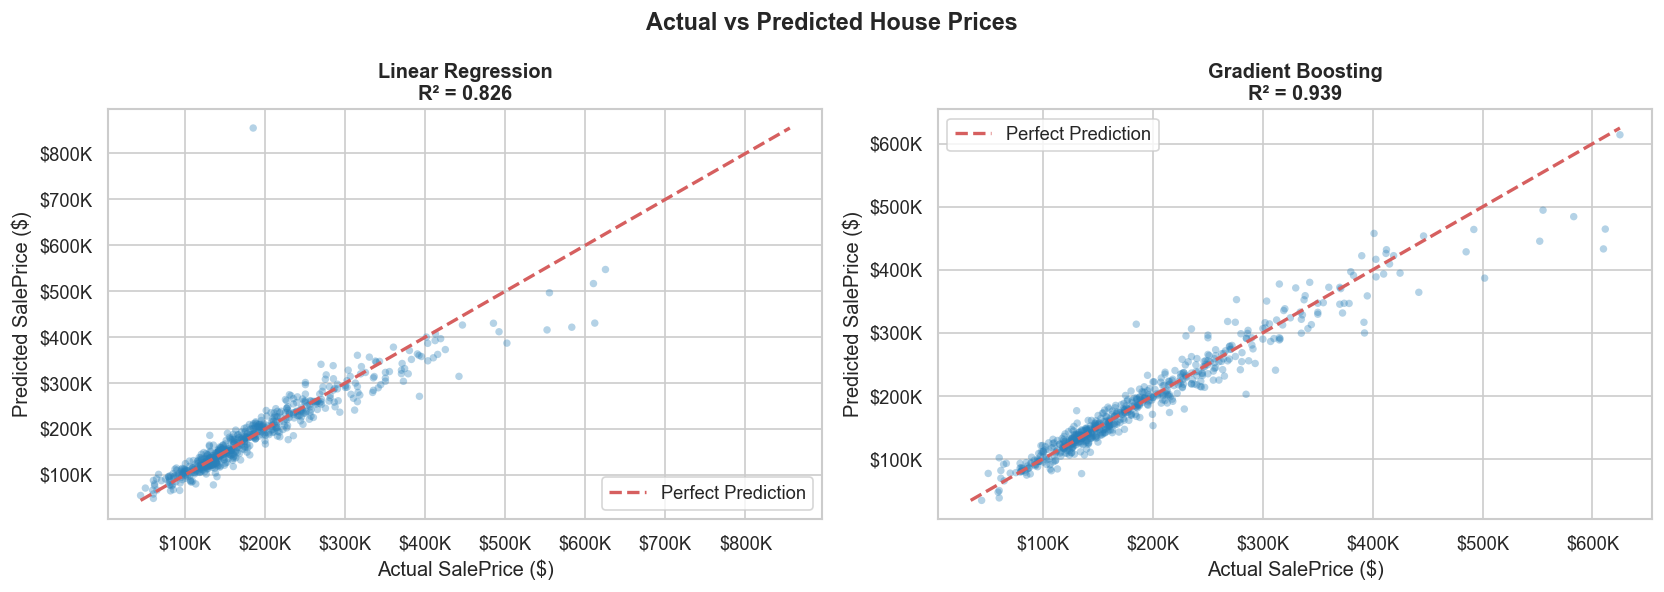

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, y_pred) in zip(axes, [('Linear Regression', y_pred_lr),
                                       ('Gradient Boosting', y_pred_gb)]):
    ax.scatter(y_test, y_pred, alpha=0.35, color='#2980b9', edgecolors='none', s=20)
    mn = min(y_test.min(), y_pred.min())
    mx = max(y_test.max(), y_pred.max())
    ax.plot([mn, mx], [mn, mx], 'r--', lw=2, label='Perfect Prediction')
    r2 = r2_score(y_test, y_pred)
    ax.set_title(f'{name}\nR² = {r2:.3f}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Actual SalePrice ($)')
    ax.set_ylabel('Predicted SalePrice ($)')
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
    ax.legend()

plt.suptitle('Actual vs Predicted House Prices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('hp_09_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()


### 6.2 Residual Plots

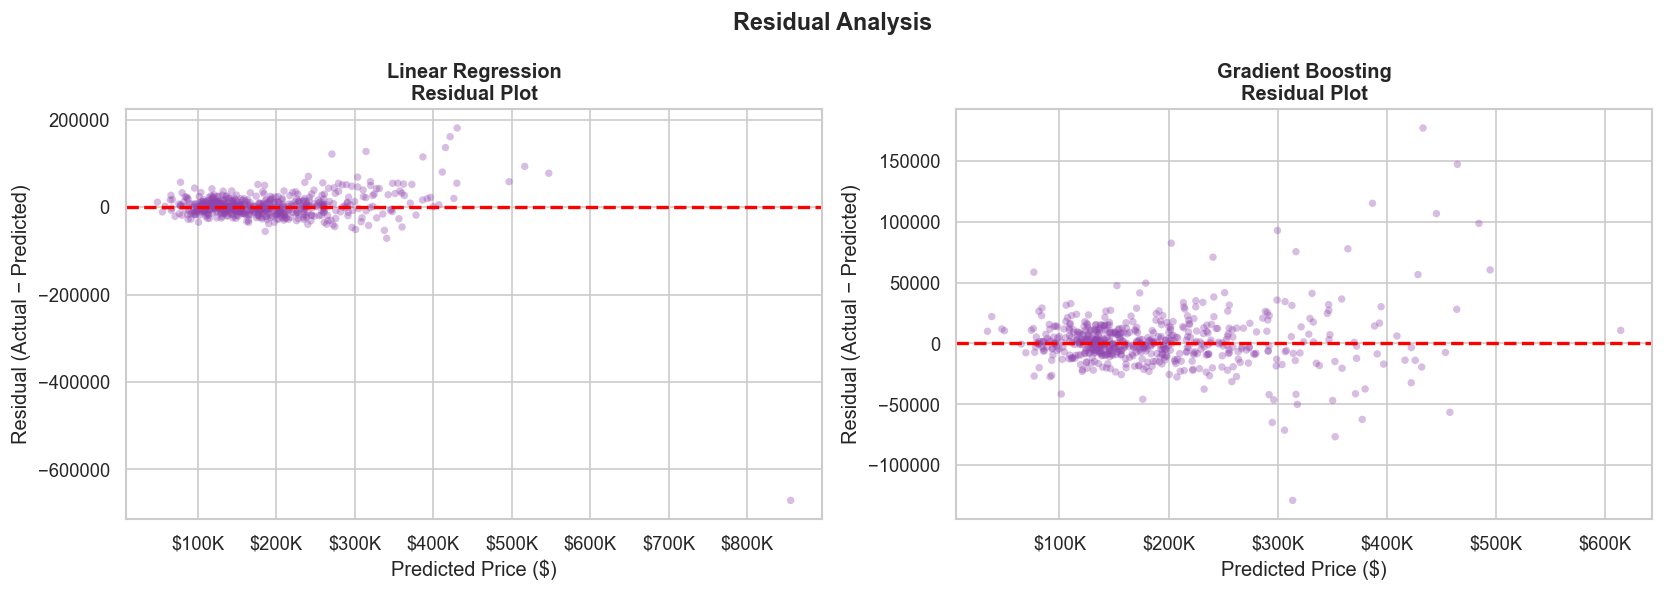

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, y_pred) in zip(axes, [('Linear Regression', y_pred_lr),
                                       ('Gradient Boosting', y_pred_gb)]):
    residuals = y_test.values - y_pred
    ax.scatter(y_pred, residuals, alpha=0.35, color='#8e44ad', edgecolors='none', s=20)
    ax.axhline(0, color='red', linestyle='--', lw=2)
    ax.set_title(f'{name}\nResidual Plot', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted Price ($)')
    ax.set_ylabel('Residual (Actual − Predicted)')
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

plt.suptitle('Residual Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('hp_10_residuals.png', dpi=150, bbox_inches='tight')
plt.show()


### 6.3 Residual Distribution

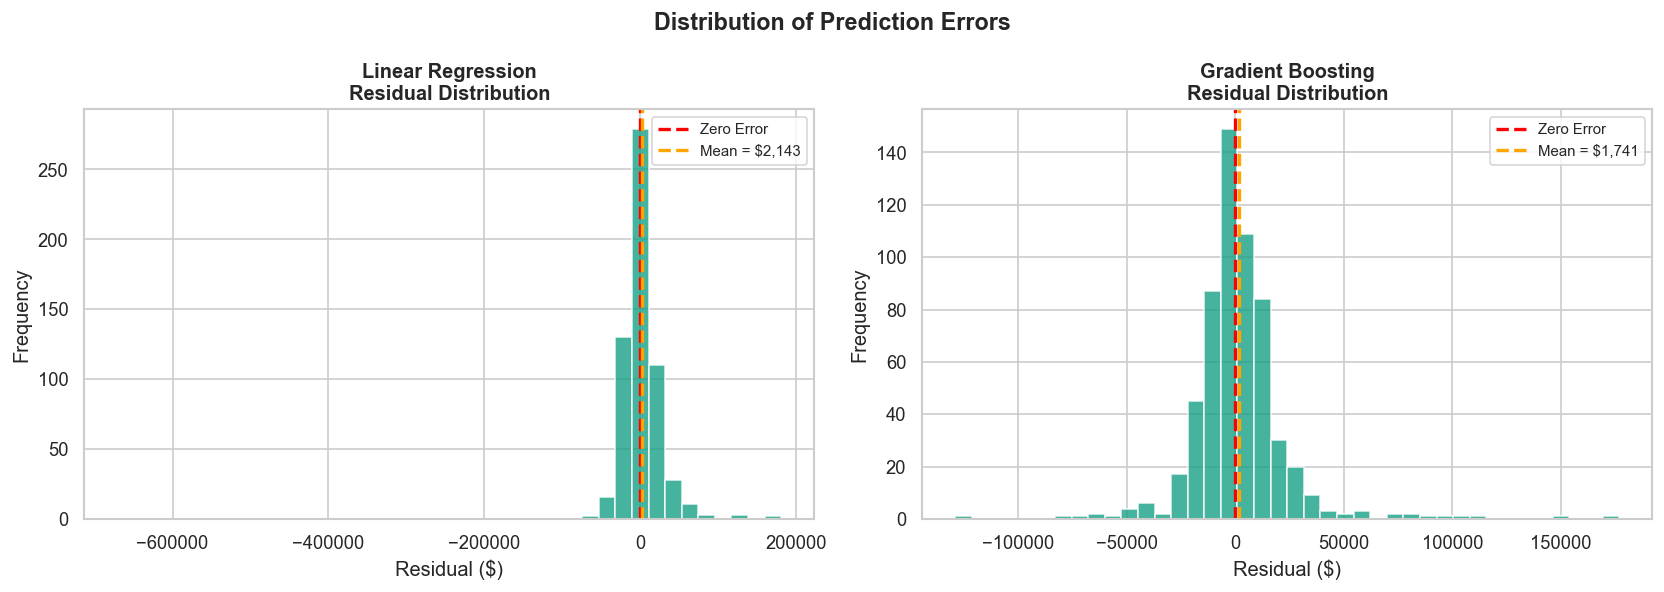

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, y_pred) in zip(axes, [('Linear Regression', y_pred_lr),
                                       ('Gradient Boosting', y_pred_gb)]):
    residuals = y_test.values - y_pred
    ax.hist(residuals, bins=40, color='#16a085', edgecolor='white', alpha=0.8)
    ax.axvline(0, color='red', lw=2, linestyle='--', label='Zero Error')
    ax.axvline(residuals.mean(), color='orange', lw=2, linestyle='--',
               label=f'Mean = ${residuals.mean():,.0f}')
    ax.set_title(f'{name}\nResidual Distribution', fontsize=12, fontweight='bold')
    ax.set_xlabel('Residual ($)')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=9)

plt.suptitle('Distribution of Prediction Errors', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('hp_11_residual_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


### 6.4 Model Comparison Summary

             MODEL PERFORMANCE SUMMARY
Model                            MAE         RMSE       R²
----------------------------------------------------------
Linear Regression         $   17,504 $     37,369   0.8258
Gradient Boosting         $   13,300 $     22,157   0.9388

Best Model by R²: Gradient Boosting


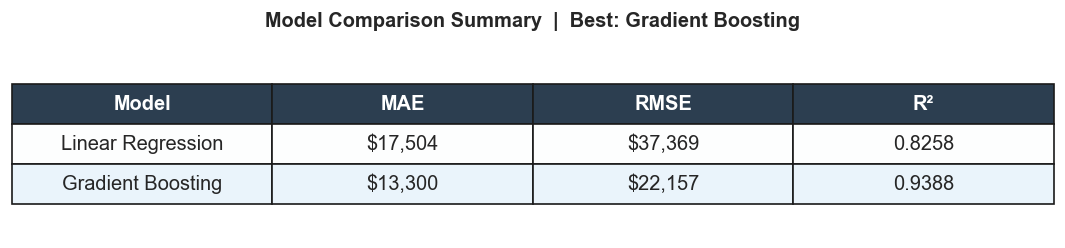

In [36]:
print("=" * 58)
print("             MODEL PERFORMANCE SUMMARY")
print("=" * 58)
print(f"{'Model':<25} {'MAE':>10} {'RMSE':>12} {'R²':>8}")
print("-" * 58)
print(f"{'Linear Regression':<25} ${mae_lr:>9,.0f} ${rmse_lr:>11,.0f} {r2_lr:>8.4f}")
print(f"{'Gradient Boosting':<25} ${mae_gb:>9,.0f} ${rmse_gb:>11,.0f} {r2_gb:>8.4f}")
print("=" * 58)

best = 'Logistic Regression' if r2_lr >= r2_gb else 'Gradient Boosting'
print(f"\nBest Model by R²: {best}")

# Visual table
fig, ax = plt.subplots(figsize=(8, 2))
ax.axis('off')
table_data = [
    ['Linear Regression', f'${mae_lr:,.0f}', f'${rmse_lr:,.0f}', f'{r2_lr:.4f}'],
    ['Gradient Boosting', f'${mae_gb:,.0f}', f'${rmse_gb:,.0f}', f'{r2_gb:.4f}'],
]
table = ax.table(cellText=table_data,
                 colLabels=['Model', 'MAE', 'RMSE', 'R²'],
                 cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.4, 2)
for j in range(4):
    table[0, j].set_facecolor('#2c3e50')
    table[0, j].set_text_props(color='white', fontweight='bold')
for i in range(1, 3):
    for j in range(4):
        table[i, j].set_facecolor('#eaf4fb' if i % 2 == 0 else '#fdfefe')

plt.title(f'Model Comparison Summary  |  Best: {best}', fontsize=12, fontweight='bold', pad=15)
plt.savefig('hp_12_model_comparison_table.png', dpi=150, bbox_inches='tight')
plt.show()


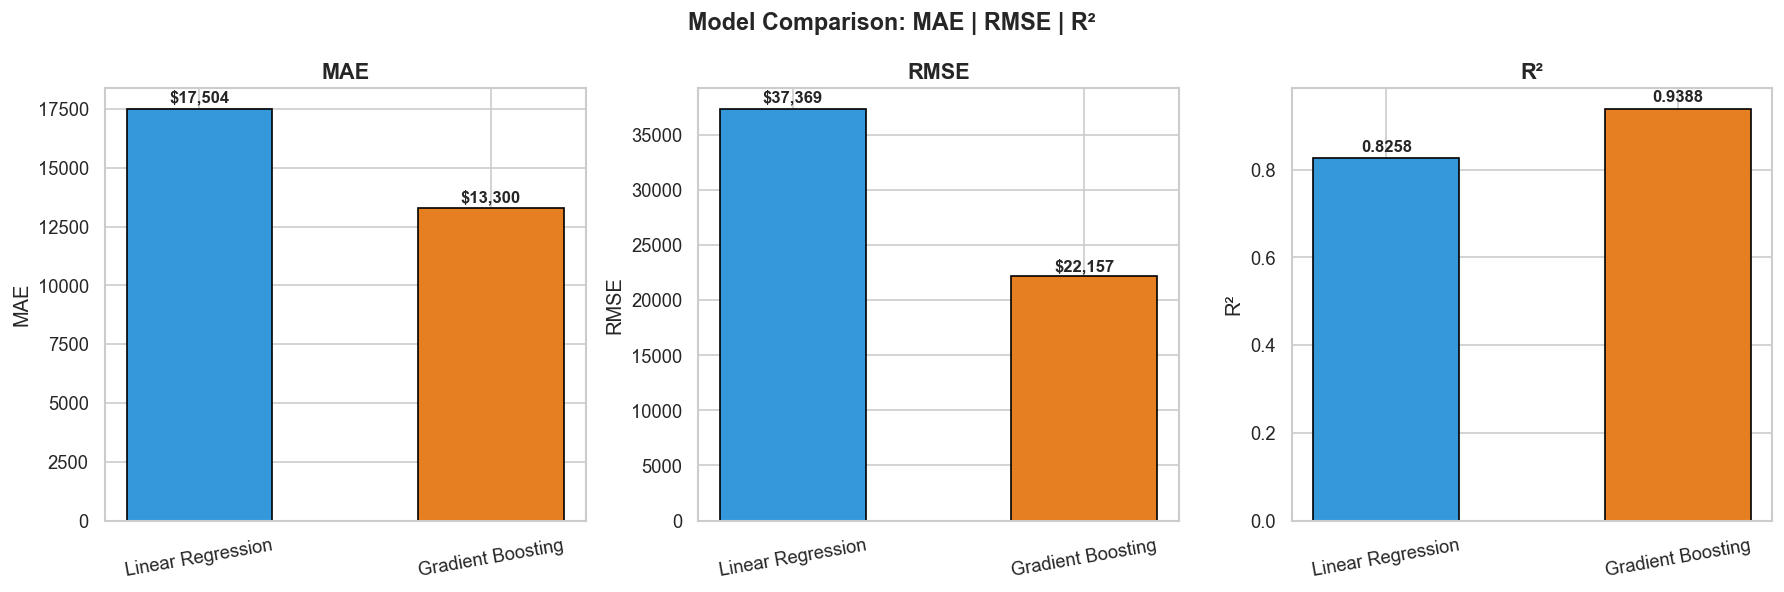

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = ['#3498db', '#e67e22']

for ax, (metric, vals) in zip(axes, [
    ('MAE',  [mae_lr, mae_gb]),
    ('RMSE', [rmse_lr, rmse_gb]),
    ('R²',   [r2_lr, r2_gb])
]):
    bars = ax.bar(['Linear Regression', 'Gradient Boosting'], vals,
                  color=colors, edgecolor='black', width=0.5)
    for bar in bars:
        h = bar.get_height()
        label = f'{h:.4f}' if metric == 'R²' else f'${h:,.0f}'
        ax.text(bar.get_x() + bar.get_width()/2, h * 1.01, label,
                ha='center', va='bottom', fontweight='bold', fontsize=10)
    ax.set_title(metric, fontweight='bold', fontsize=13)
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=10)

plt.suptitle('Model Comparison: MAE | RMSE | R²', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('hp_12_model_comparison_bars.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 7. Feature Importance Analysis

### 7.1 Linear Regression - Top 15 Coefficients

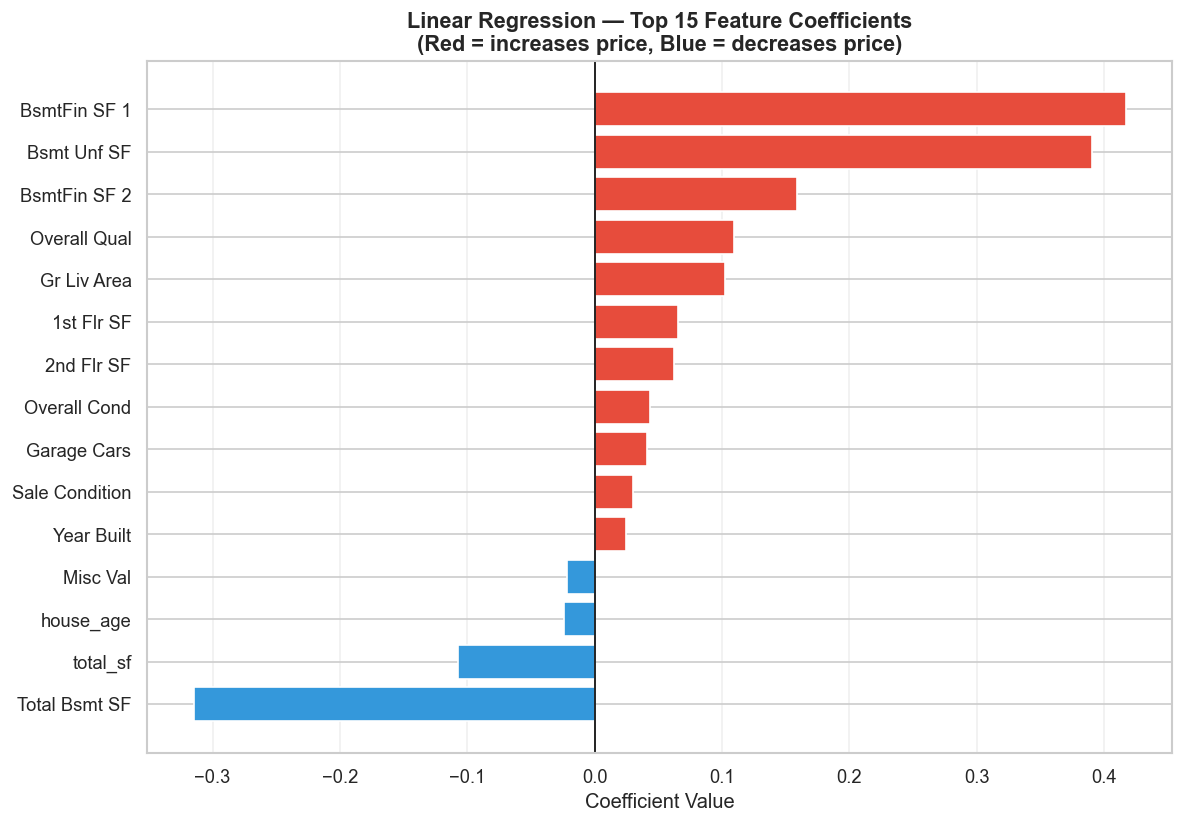

In [38]:
feature_names = X.columns.tolist()
lr_coefs = pd.Series(lr_model.coef_, index=feature_names)
top_lr = lr_coefs.abs().sort_values(ascending=False).head(15)
top_lr_vals = lr_coefs[top_lr.index].sort_values()

colors = ['#e74c3c' if c > 0 else '#3498db' for c in top_lr_vals]

plt.figure(figsize=(10, 7))
plt.barh(top_lr_vals.index, top_lr_vals.values, color=colors, edgecolor='white')
plt.axvline(0, color='black', lw=1)
plt.xlabel('Coefficient Value', fontsize=12)
plt.title('Linear Regression — Top 15 Feature Coefficients\n(Red = increases price, Blue = decreases price)',
          fontsize=13, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('hp_13_lr_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()


### 7.2 Gradient Boosting - Top 15 Feature Importance

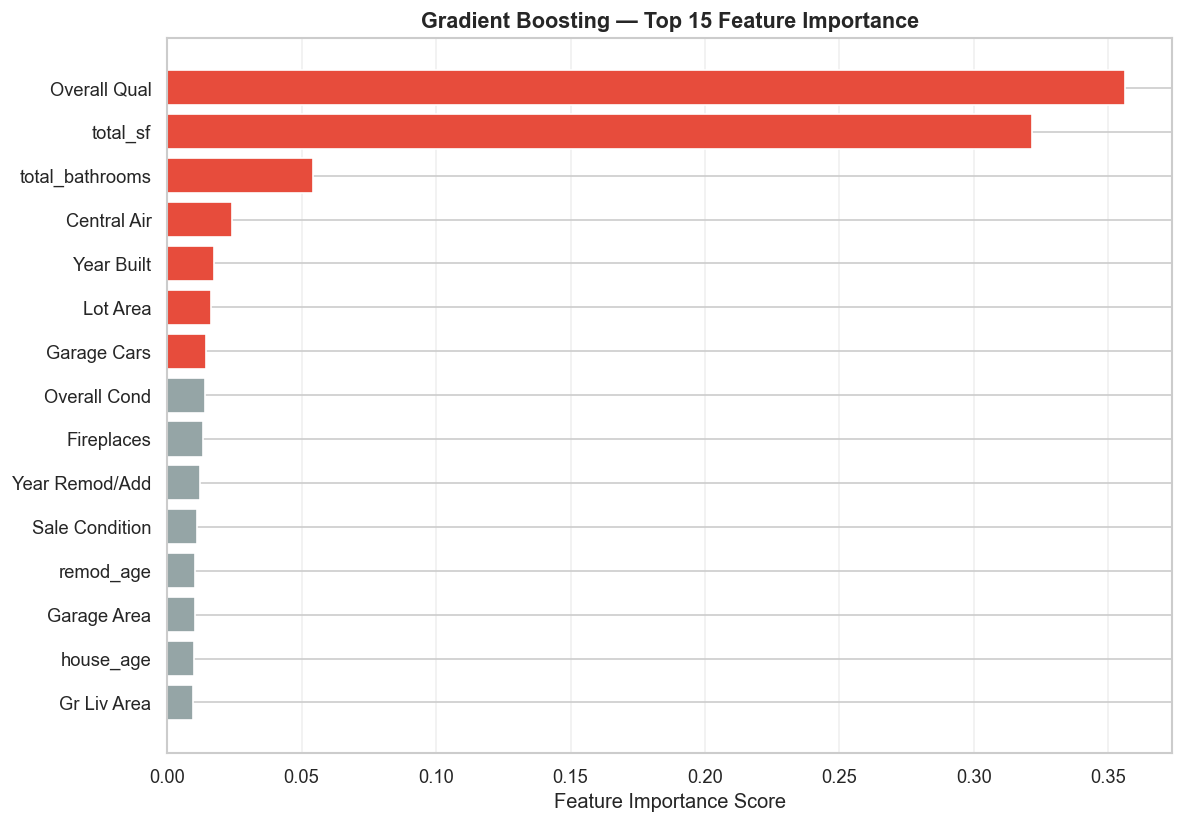

Top 10 most important features (Gradient Boosting):
Overall Qual       0.356060
total_sf           0.321682
total_bathrooms    0.054195
Central Air        0.024227
Year Built         0.017574
Lot Area           0.016205
Garage Cars        0.014460
Overall Cond       0.013931
Fireplaces         0.013281
Year Remod/Add     0.012268


In [39]:
gb_importance = pd.Series(gb_model.feature_importances_,
                          index=feature_names).sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 7))
colors = ['#e74c3c' if v > gb_importance.median() else '#95a5a6'
          for v in gb_importance.sort_values()]
plt.barh(gb_importance.sort_values().index,
         gb_importance.sort_values().values, color=colors, edgecolor='white')
plt.xlabel('Feature Importance Score', fontsize=12)
plt.title('Gradient Boosting — Top 15 Feature Importance', fontsize=13, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('hp_14_gb_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 10 most important features (Gradient Boosting):")
print(gb_importance.head(10).to_string())


---
## 8. Making Predictions


### 8.1 Predictions on the Test Set

In [40]:
results_df = X_test.copy().reset_index(drop=True)
results_df['Actual_Price'] = y_test.values
results_df['LR_Predicted'] = y_pred_lr.round(0)
results_df['GB_Predicted'] = y_pred_gb.round(0)
results_df['LR_Error_%']   = (np.abs(results_df['Actual_Price'] - results_df['LR_Predicted']) / results_df['Actual_Price'] * 100).round(1)
results_df['GB_Error_%']   = (np.abs(results_df['Actual_Price'] - results_df['GB_Predicted']) / results_df['Actual_Price'] * 100).round(1)

print("Sample Predictions (first 10 houses):")
display_cols = ['Actual_Price', 'LR_Predicted', 'LR_Error_%', 'GB_Predicted', 'GB_Error_%']
print(results_df[display_cols].head(10).to_string())


Sample Predictions (first 10 houses):
   Actual_Price  LR_Predicted  LR_Error_%  GB_Predicted  GB_Error_%
0        161000      171994.0         6.8      145761.0         9.5
1        116000      124458.0         7.3      104098.0        10.3
2        196500      205874.0         4.8      192617.0         2.0
3        123600      117450.0         5.0      116769.0         5.5
4        126000      123800.0         1.7      116541.0         7.5
5        174190      191050.0         9.7      174098.0         0.1
6        200000      166726.0        16.6      152587.0        23.7
7        148500      150019.0         1.0      148758.0         0.2
8         88750      114462.0        29.0       93220.0         5.0
9        409900      354707.0        13.5      393242.0         4.1


### 8.2 Predicted vs Actual - Sorted Line Chart


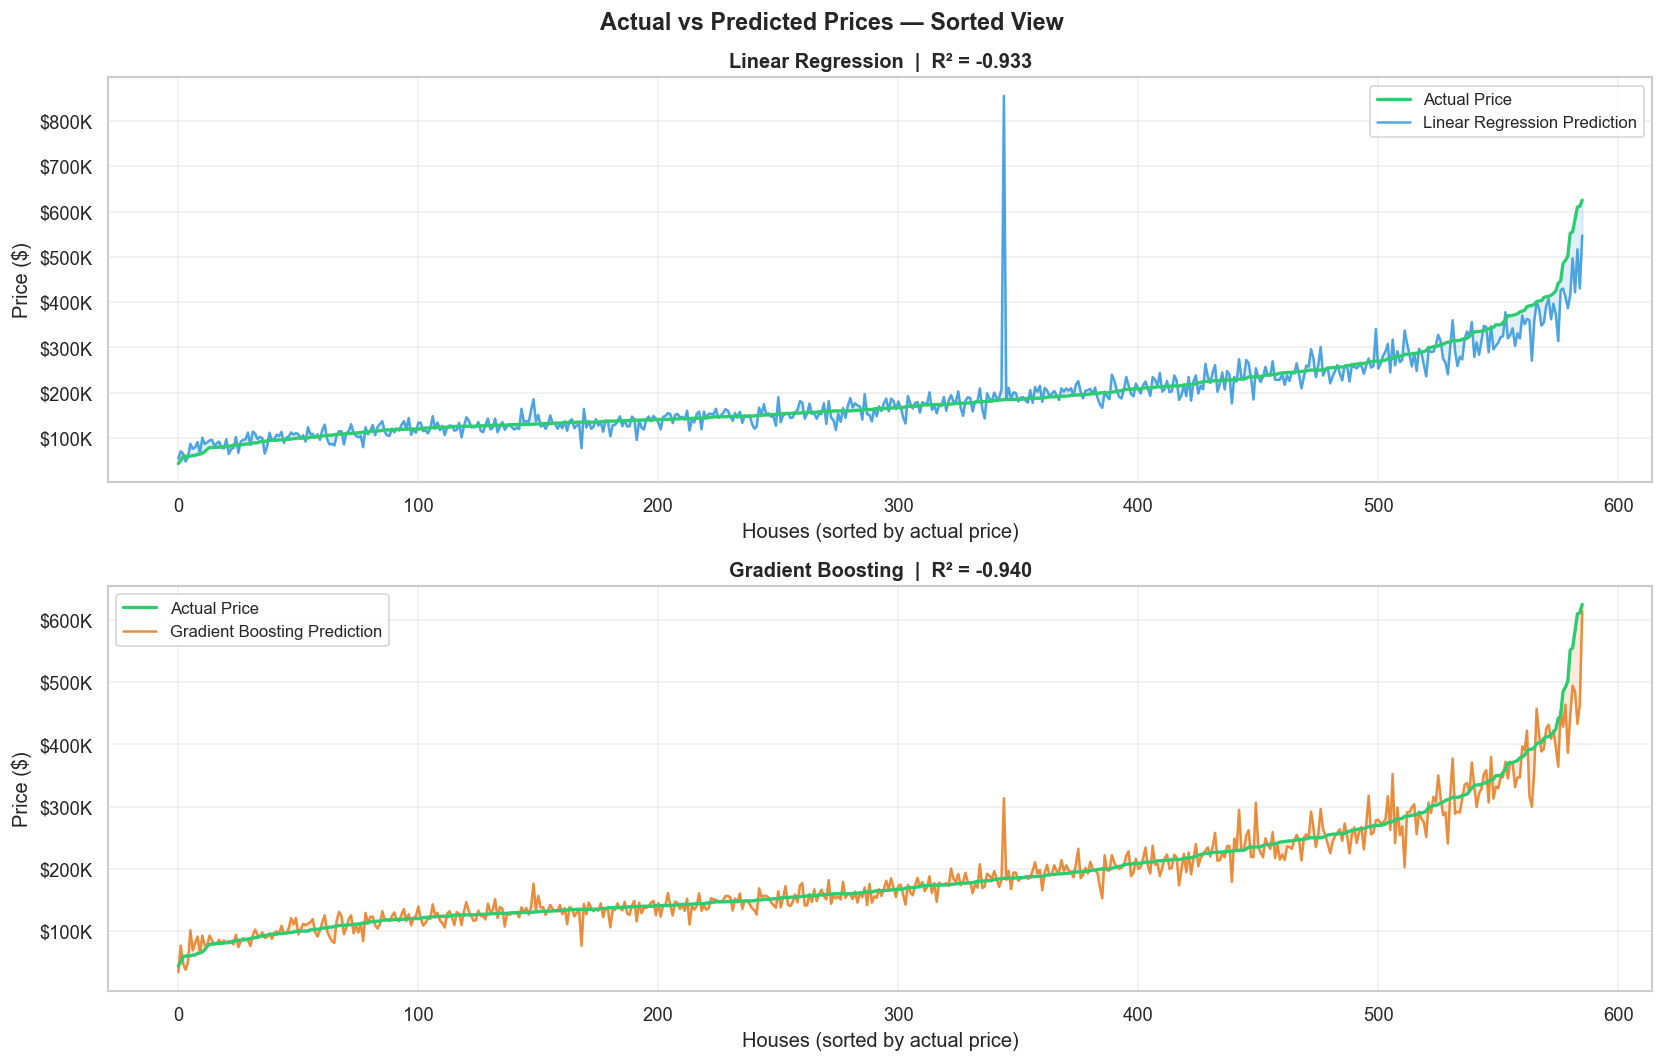

In [41]:
sorted_idx     = np.argsort(y_test.values)
actual_sorted  = y_test.values[sorted_idx]
lr_sorted      = y_pred_lr[sorted_idx]
gb_sorted      = y_pred_gb[sorted_idx]
x_axis         = np.arange(len(actual_sorted))

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

for ax, (name, preds, color) in zip(axes, [
    ('Linear Regression', lr_sorted, '#3498db'),
    ('Gradient Boosting', gb_sorted, '#e67e22')
]):
    ax.fill_between(x_axis, actual_sorted, preds, alpha=0.15, color=color)
    ax.plot(x_axis, actual_sorted, color='#2ecc71', lw=2, label='Actual Price', zorder=3)
    ax.plot(x_axis, preds, color=color, lw=1.5, alpha=0.85,
            label=f'{name} Prediction', zorder=2)
    r2 = r2_score(y_test, preds)
    ax.set_title(f'{name}  |  R² = {r2:.3f}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Houses (sorted by actual price)')
    ax.set_ylabel('Price ($)')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)

plt.suptitle('Actual vs Predicted Prices — Sorted View', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('hp_15_sorted_predictions.png', dpi=150, bbox_inches='tight')
plt.show()


### 8.3 Prediction Error Distribution


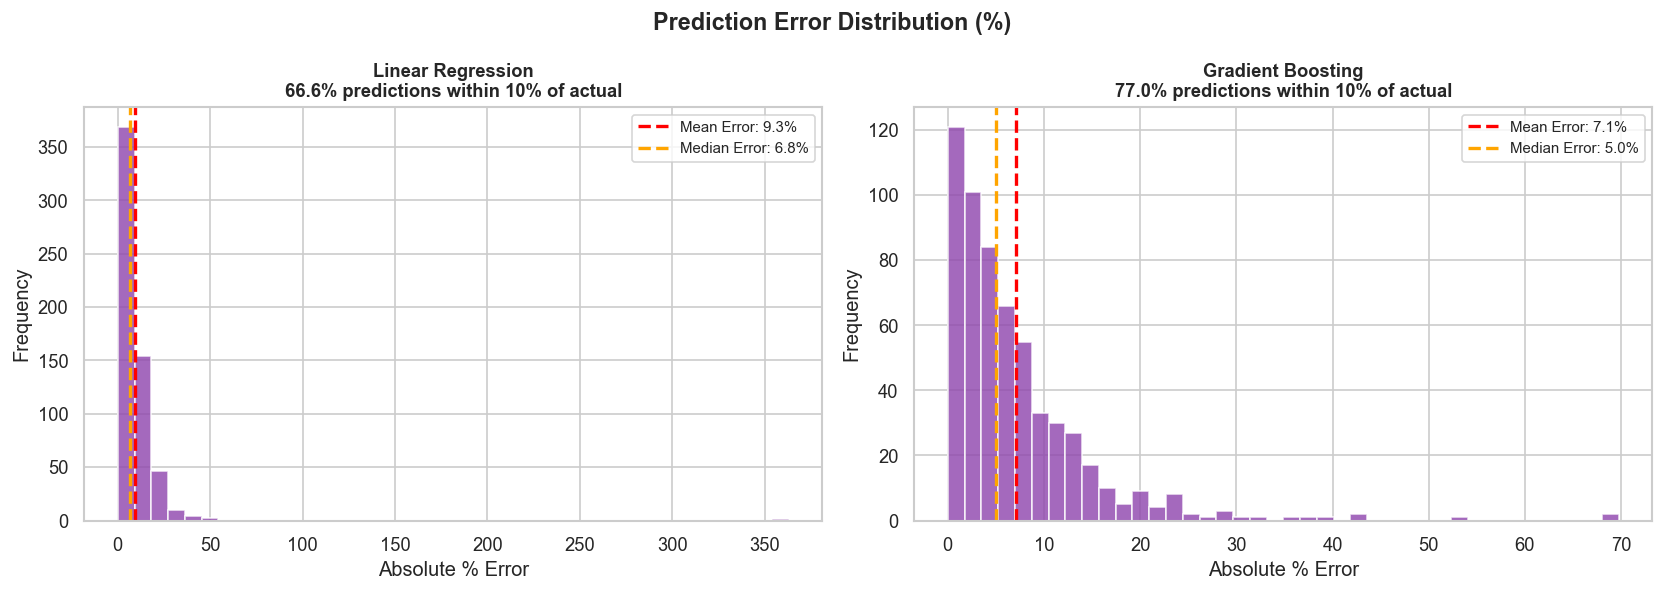

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, preds) in zip(axes, [('Linear Regression', y_pred_lr),
                                      ('Gradient Boosting', y_pred_gb)]):
    pct_errors = np.abs(y_test.values - preds) / y_test.values * 100
    ax.hist(pct_errors, bins=40, color='#8e44ad', edgecolor='white', alpha=0.8)
    ax.axvline(pct_errors.mean(), color='red', lw=2, linestyle='--',
               label=f'Mean Error: {pct_errors.mean():.1f}%')
    ax.axvline(np.median(pct_errors), color='orange', lw=2, linestyle='--',
               label=f'Median Error: {np.median(pct_errors):.1f}%')
    within_10 = (pct_errors <= 10).sum() / len(pct_errors) * 100
    ax.set_title(f'{name}\n{within_10:.1f}% predictions within 10% of actual',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Absolute % Error')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=9)

plt.suptitle('Prediction Error Distribution (%)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('hp_16_error_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


### 8.4 Predict Price for a Single New House


In [45]:
# ── Build a new house using median values as defaults ────────────────────────
medians = X_train.median().to_dict()

# Override specific features to define our custom house
custom_overrides = {
    'Overall Qual' : 7,       # Good quality (out of 10)
    'Gr Liv Area'  : 1800,    # 1800 sq ft living area
    'Garage Cars'  : 2,       # 2-car garage
    'Year Built'   : 2005,    # Built in 2005
    'Full Bath'    : 2,
    'Bedroom AbvGr': 3,
    'house_age'    : 2024 - 2005,
    'total_sf'     : 1800 + 800,   # living + basement
}

new_house = {**medians, **custom_overrides}
house_df  = pd.DataFrame([new_house])[X.columns]

# Predict
house_scaled = scaler.transform(house_df)
lr_price     = np.expm1(lr_model.predict(house_scaled)[0])
gb_price     = np.expm1(gb_model.predict(house_df)[0])

print("=" * 55)
print("        SINGLE HOUSE PRICE PREDICTION")
print("=" * 55)
print(f"  Overall Quality  : {custom_overrides['Overall Qual']}/10")
print(f"  Living Area      : {custom_overrides['Gr Liv Area']:,} sq ft")
print(f"  Garage           : {custom_overrides['Garage Cars']} cars")
print(f"  Year Built       : {custom_overrides['Year Built']}")
print(f"  Bedrooms         : {custom_overrides['Bedroom AbvGr']}")
print(f"  Full Bathrooms   : {custom_overrides['Full Bath']}")
print("-" * 55)
print(f"  Linear Regression  : ${lr_price:>12,.0f}")
print(f"  Gradient Boosting  : ${gb_price:>12,.0f}")
print(f"  Average Estimate   : ${(lr_price+gb_price)/2:>12,.0f}")
print("=" * 55)


        SINGLE HOUSE PRICE PREDICTION
  Overall Quality  : 7/10
  Living Area      : 1,800 sq ft
  Garage           : 2 cars
  Year Built       : 2005
  Bedrooms         : 3
  Full Bathrooms   : 2
-------------------------------------------------------
  Linear Regression  : $     163,721
  Gradient Boosting  : $     184,406
  Average Estimate   : $     174,063


### 8.5 Price Estimate Visual


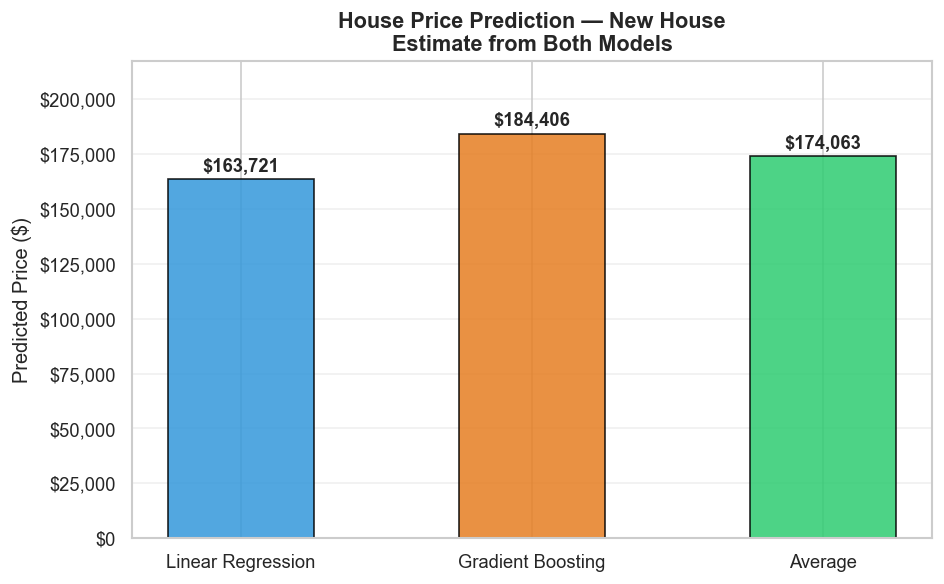

In [46]:
fig, ax = plt.subplots(figsize=(8, 5))

model_names = ['Linear Regression', 'Gradient Boosting', 'Average']
predictions = [lr_price, gb_price, (lr_price + gb_price) / 2]
bar_colors  = ['#3498db', '#e67e22', '#2ecc71']

bars = ax.bar(model_names, predictions, color=bar_colors, edgecolor='black', width=0.5, alpha=0.85)

for bar, val in zip(bars, predictions):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
            f'${val:,.0f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylabel('Predicted Price ($)', fontsize=12)
ax.set_title('House Price Prediction — New House\nEstimate from Both Models',
             fontsize=13, fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_ylim(0, max(predictions) * 1.18)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('hp_17_single_house_prediction.png', dpi=150, bbox_inches='tight')
plt.show()


### 8.6 Batch Predictions - Multiple Houses


In [49]:
# 5 houses with varying quality/size profiles
batch_overrides = [
    {'Overall Qual': 4, 'Gr Liv Area': 900,  'Garage Cars': 1, 'Year Built': 1970, 'Full Bath': 1, 'Bedroom AbvGr': 2},
    {'Overall Qual': 6, 'Gr Liv Area': 1400, 'Garage Cars': 1, 'Year Built': 1990, 'Full Bath': 2, 'Bedroom AbvGr': 3},
    {'Overall Qual': 7, 'Gr Liv Area': 1800, 'Garage Cars': 2, 'Year Built': 2000, 'Full Bath': 2, 'Bedroom AbvGr': 3},
    {'Overall Qual': 8, 'Gr Liv Area': 2400, 'Garage Cars': 2, 'Year Built': 2008, 'Full Bath': 3, 'Bedroom AbvGr': 4},
    {'Overall Qual': 10,'Gr Liv Area': 3500, 'Garage Cars': 3, 'Year Built': 2015, 'Full Bath': 4, 'Bedroom AbvGr': 5},
]

batch_houses = []
for overrides in batch_overrides:
    row = {**medians, **overrides}
    row['house_age']  = 2024 - overrides['Year Built']
    row['total_sf']   = overrides['Gr Liv Area'] + medians.get('Total Bsmt SF', 0)
    row['total_bathrooms'] = overrides['Full Bath']
    batch_houses.append(row)

batch_df = pd.DataFrame(batch_houses)[X.columns]
batch_scaled    = scaler.transform(batch_df)
batch_lr_preds  = np.expm1(lr_model.predict(batch_scaled))
batch_gb_preds  = np.expm1(gb_model.predict(batch_df))

batch_results = pd.DataFrame({
    'Quality'   : [o['Overall Qual'] for o in batch_overrides],
    'Area_sqft' : [o['Gr Liv Area']  for o in batch_overrides],
    'Year_Built': [o['Year Built']   for o in batch_overrides],
    'LR_Price'  : batch_lr_preds.round(0).astype(int),
    'GB_Price'  : batch_gb_preds.round(0).astype(int),
    'Avg_Price' : ((batch_lr_preds + batch_gb_preds)/2).round(0).astype(int),
})
batch_results.index = [f'House {i+1}' for i in range(5)]

print("\t\t=== BATCH PREDICTION RESULTS ===\n")
print(batch_results.to_string())


		=== BATCH PREDICTION RESULTS ===

         Quality  Area_sqft  Year_Built  LR_Price  GB_Price  Avg_Price
House 1        4        900        1970    102270    115283     108776
House 2        6       1400        1990    132611    152282     142446
House 3        7       1800        2000    158377    187700     173039
House 4        8       2400        2008    187442    249848     218645
House 5       10       3500        2015    262126    328513     295319


### 8.7 Batch Price Comparison Chart


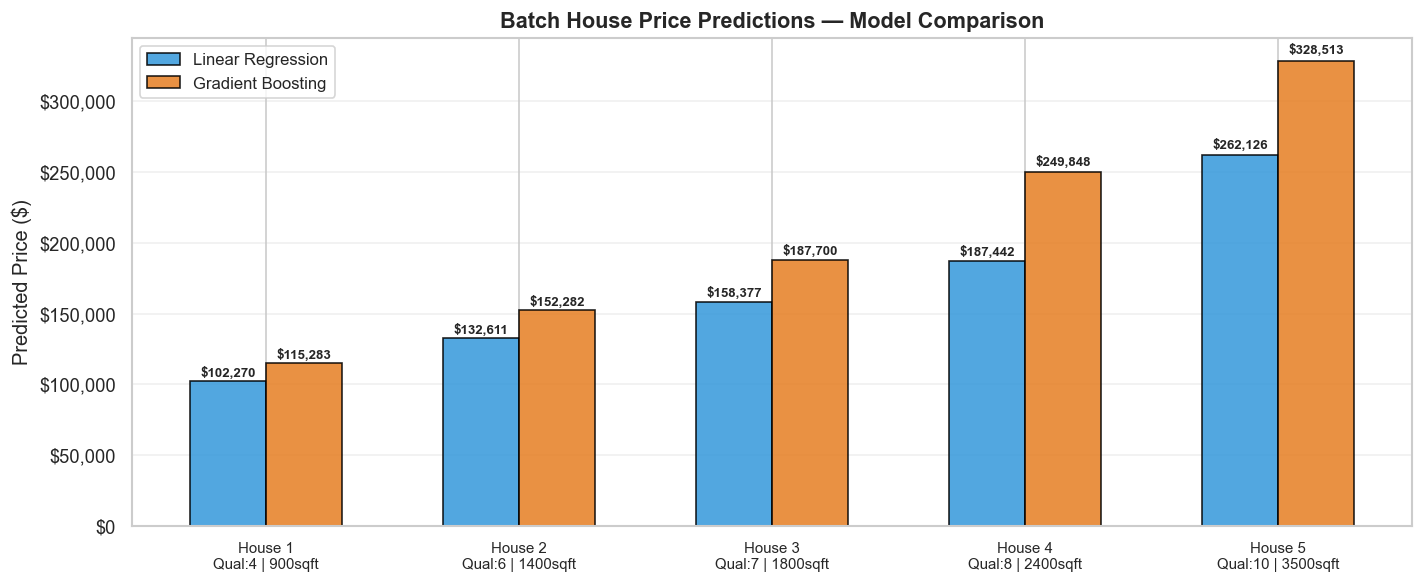

In [50]:
x = np.arange(5)
width = 0.3

fig, ax = plt.subplots(figsize=(12, 5))

b1 = ax.bar(x - width/2, batch_lr_preds, width, label='Linear Regression',
            color='#3498db', alpha=0.85, edgecolor='black')
b2 = ax.bar(x + width/2, batch_gb_preds, width, label='Gradient Boosting',
            color='#e67e22', alpha=0.85, edgecolor='black')

for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
            f'${bar.get_height():,.0f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels([f'House {i+1}\nQual:{o["Overall Qual"]} | {o["Gr Liv Area"]}sqft'
                    for i, o in enumerate(batch_overrides)], fontsize=9)
ax.set_ylabel('Predicted Price ($)')
ax.set_title('Batch House Price Predictions — Model Comparison', fontsize=13, fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'${v:,.0f}'))
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('hp_18_batch_predictions.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 9. Saving the Trained Models


In [51]:
best_r2 = 'GB' if r2_gb > r2_lr else 'LR'

joblib.dump(lr_model, 'ames_lr_model.pkl')
joblib.dump(gb_model, 'ames_gb_model.pkl')
joblib.dump(scaler,   'ames_scaler.pkl')

print("Models saved:")
print(f"   ames_lr_model.pkl  — R²: {r2_lr:.4f}")
print(f"   ames_gb_model.pkl  — R²: {r2_gb:.4f}  {'← BEST' if best_r2 == 'GB' else ''}")
print(f"   ames_scaler.pkl")
print(f"\nBest model: {'Gradient Boosting' if best_r2 == 'GB' else 'Linear Regression'}")
print("\nScaler must be used with Linear Regression. GB uses raw features.")


Models saved:
   ames_lr_model.pkl  — R²: 0.8258
   ames_gb_model.pkl  — R²: 0.9388  ← BEST
   ames_scaler.pkl

Best model: Gradient Boosting

Scaler must be used with Linear Regression. GB uses raw features.


---
## 10. Key Insights and Findings

### Model Performance

| Model | MAE | RMSE | R² | Recommended |
|---|---|---|---|---|
| Linear Regression | \$17,504 | \$37,369 | 0.8258 | No |
| Gradient Boosting | \$13,300 | \$22,157 | 0.9388 | Yes |

- **Gradient Boosting is the recommended model** - R² of 0.9388 means it explains 93.88% of price variation, which is excellent
- Gradient Boosting outperformed Linear Regression significantly (R²: 0.9388 vs 0.8258) by capturing non-linear feature interactions

### Most Important Features

Based on Gradient Boosting importance, top price drivers in Ames:

| Feature | Why It Matters |
|---|---|
| `Overall Qual` | Single strongest predictor - quality rating 1-10 |
| `Gr Liv Area` | Larger living area = higher price |
| `total_sf` | Combined basement + living area |
| `house_age` | Newer houses command a premium |
| `Neighborhood` | Location is a major price driver |
| `Garage Cars` | Garage capacity reflects property size |

### Preprocessing Decisions
- Columns with >40% missing values were dropped (too sparse to be useful)
- Remaining missing values filled with median (numerical) and mode (categorical)
- All categorical columns label-encoded
- Log1p transform on SalePrice reduced skewness and improved model fit
- Feature engineering (house_age, total_sf, total_bathrooms) added meaningful composite signals

---
## 11. Conclusion

In this project, we successfully:

1. **Loaded and explored** the Ames Housing Dataset (1,460 houses, 79 features)
2. **Performed EDA** - price distribution, scatter plots, neighborhood analysis, quality impact, correlation heatmap, outlier detection
3. **Preprocessed** data - dropped high-missing columns, filled NaNs, encoded categoricals, engineered new features, scaled with before/after comparison
4. **Trained two models** - Linear Regression and Gradient Boosting (both on log-transformed target)
5. **Evaluated** using MAE, RMSE, R², actual vs predicted plots, and residual analysis
6. **Analyzed feature importance** - LR coefficients and GB importance scores
7. **Made predictions** - test set results, single house estimate, batch predictions
8. **Saved models** using joblib

> **Key Takeaway:** Overall quality rating (`Overall Qual`) and living area (`Gr Liv Area`) are the strongest price drivers in the Ames dataset. Gradient Boosting with R² of 0.9388 is the recommended model. Log-transforming the skewed SalePrice target and feature engineering were the key decisions that drove this strong performance.
